# Семинар 1 — Введение в RL, MDP и уравнения Беллмана

**0. Пролог и цели (10 мин)**

- Осмыслить цикл агент–среда–награда и формализм MDP.
- Понять роли $V^\pi$, $Q^\pi$, $\pi$ и уравнения Беллмана.
- Связать формулы с кодом и экспериментами. См. `theory.md` §2–5.



## 0b. Импорты семинара (из src/)

In [45]:
!pip --quiet install "gymnasium[other]"

In [28]:
# Импортируем модули семинара из ../../src
import sys, os
sys.path.append(os.path.abspath(os.path.join('..','..','src')))
from rlcourse.sem01.envs import make_cartpole, make_frozenlake, SEED
from rlcourse.sem01.algorithms import run_random, eval_value_mc, q_learning, td0_value_learning, moving_avg, smooth, eval_greedy
from rlcourse.sem01.discretization import discretize, make_edges, BIN_COUNTS, bounds
from rlcourse.sem01.policies import epsilon_greedy, softmax_action, random_policy_from_env
from rlcourse.sem01.video import record_episodes


## 0a. Установка и воспроизводимость

        Блок для проверки версий и воспроизводимости. Установка через pip — опционально, по необходимости.

In [29]:
# Установка (по необходимости):
# !pip install -q gymnasium==0.29.1 matplotlib numpy
# !pip install -q gymnasium[box2d]

import sys, os, platform, random
import numpy as np
import matplotlib
import gymnasium as gym

SEED = 42
np.random.seed(SEED); random.seed(SEED)

print('Python:', sys.version.split()[0])
print('OS:', platform.platform())
print('gymnasium:', gym.__version__)
print('numpy:', np.__version__)
print('matplotlib:', matplotlib.__version__)
print('SEED:', SEED)

Python: 3.13.5
OS: macOS-26.0.1-arm64-arm-64bit-Mach-O
gymnasium: 1.2.1
numpy: 2.2.6
matplotlib: 3.10.7
SEED: 42


## 1. MDP-анатомия среды (`CartPole-v1`)

Разбираем соответствие компонентов MDP и API Gymnasium:\n
- `observation_space` → $\mathcal S$ (состояния),\n
- `action_space` → $\mathcal A$ (действия),\n
- переход `step(a)` даёт `(s', r, done, trunc, info)` → $P,r$.


In [30]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print('gymnasium:', gym.__version__)
print('numpy:', np.__version__)
print('SEED:', SEED)

env = make_cartpole()
env.action_space.seed(SEED)

print('S =', getattr(env.observation_space, 'shape', None))
print('A =', getattr(env.action_space, 'n', env.action_space))
print('reward_range =', getattr(env, 'reward_range', 'N/A'))

s, info = env.reset(seed=SEED)
a = env.action_space.sample()
s_next, r, done, trunc, info = env.step(a)
print('Transition sample:', {'s': s.tolist(), 'a': int(a), 'r': float(r), 'done': bool(done)})


gymnasium: 1.2.1
numpy: 2.2.6
SEED: 42
S = (4,)
A = 2
reward_range = N/A
Transition sample: {'s': [0.02739560417830944, -0.006112155970185995, 0.03585979342460632, 0.019736802205443382], 'a': 0, 'r': 1.0, 'done': False}


In [31]:
# env готов к использованию в следующих разделах


## 2. Random policy и базовые возвраты

См. формулу возврата $G_t=\sum_k \gamma^k r_{t+k+1}$ в `theory.md` §2.

In [32]:
returns, details = run_random(env, episodes=20, gamma=0.99, seed=SEED, log_first=2, log_steps=5, return_details=True)
print('Returns:', returns)
print('Mean:', np.mean(returns).round(2))
print('Sample transitions (first episode):', len(details[0]))


Returns: [25.28279057 11.36151283 13.99416454 11.36151283 12.2478977  22.99568542
 20.63857164 42.464525   10.46617457 14.85422289 13.99416454 45.8314924
 35.73883979 28.94467727 11.36151283 15.70568066 16.54862385 50.51613404
 19.83694105 28.22694674]
Mean: 22.62
Sample transitions (first episode): 5


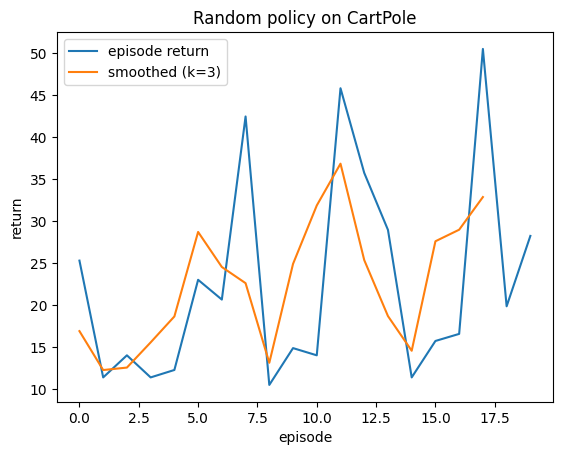

In [33]:
plt.figure()
plt.plot(returns, label='episode return')
plt.plot(smooth(returns, 3), label='smoothed (k=3)')
plt.xlabel('episode'); plt.ylabel('return'); plt.title('Random policy on CartPole')
plt.legend(); plt.show()


### Видео-демо (CartPole, random policy)

            Запишем 1 эпизод выполнения случайной политики и встроим видео ниже.

In [34]:
from pathlib import Path
from IPython.display import HTML, Video, display
import os

try:
    from rlcourse.sem01.video import record_episodes, default_video_dir
except Exception as e:
    raise ImportError(f"Failed to import video utilities: {e}")

try:
    SEED = globals().get("SEED", 42)

    video_dir = default_video_dir()
    video_dir.mkdir(parents=True, exist_ok=True)

    video_files = record_episodes(
        env_name="CartPole-v1",
        num_episodes=1,
        video_folder=str(video_dir),
        name_prefix="cartpole-random",
        seed=SEED,
    )

    if video_files:
        vf = sorted(video_files)[0]
        vf_path = (video_dir / vf).resolve()
        if not vf_path.exists():
            raise FileNotFoundError(f"Video file not found: {vf_path}")

        display(Video(str(vf_path), embed=True, width=480))

        html = f"""
        <video width="480" controls>
          <source src="{vf_path.as_posix()}" type="video/mp4">
          Your browser does not support the video tag.
        </video>
        """
        display(HTML(html))
    else:
        print("No episodes recorded (video list is empty).")

except Exception as e:
    print("Video recording is unavailable:", e)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/denissamatov/ML/RL/RL_course/sem01_mdp_bellman/assets/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Video recording is unavailable: pygame is not installed, run `pip install "gymnasium[classic-control]"`


## 3. Монте-Карло оценка $V^\pi$

Реализация ожидания через усреднение по эпизодам (см. `theory.md` §3–4).

MC estimate of V^pi: mean=19.16 ± 1.22 (95% CI)


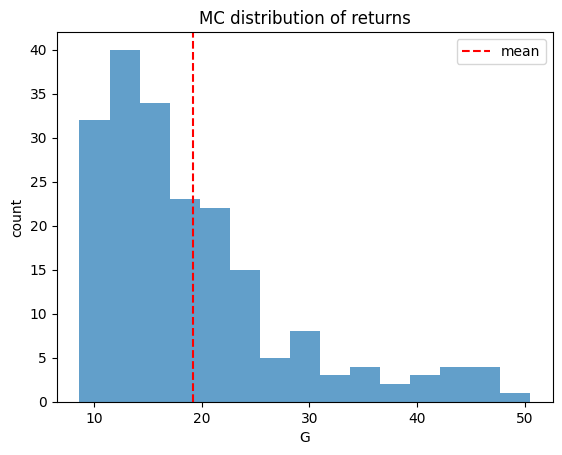

: 

In [ ]:
mc_env = make_cartpole()
rand_policy = random_policy_from_env(mc_env)
mean_G, std_G, ci95, totals = eval_value_mc(mc_env, rand_policy, episodes=200, seed=SEED, gamma=0.99)
print(f'MC estimate of V^pi: mean={mean_G:.2f} ± {ci95:.2f} (95% CI)')

plt.figure()
plt.hist(totals, bins=15, alpha=0.7)
plt.axvline(mean_G, color='r', linestyle='--', label='mean')
plt.title('MC distribution of returns'); plt.xlabel('G'); plt.ylabel('count'); plt.legend(); plt.show()

mc_env.close()


### Exercise: сравнение влияния γ (MC)

            Сравните распределение возвратов при γ ∈ {0.90, 0.99, 1.0}. Поясните влияние γ на среднее и дисперсию.

γ=0.9: mean=8.44, std=1.02, n=300
γ=0.99: mean=19.04, std=8.61, n=300
γ=1.0: mean=21.66, std=11.70, n=300


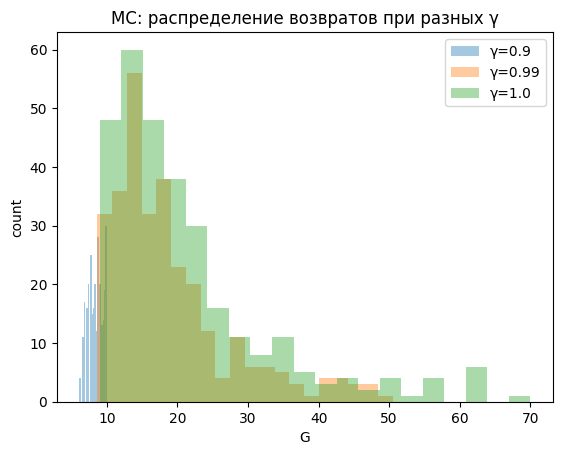

: 

In [ ]:
gammas = [0.90, 0.99, 1.0]
episodes = 300
results = {}
for gamma in gammas:
    env_mc = make_cartpole()
    policy = random_policy_from_env(env_mc)
    mean, std, _, totals = eval_value_mc(env_mc, policy, episodes=episodes, seed=SEED, gamma=gamma)
    results[gamma] = totals
    env_mc.close()
    print(f'γ={gamma}: mean={mean:.2f}, std={std:.2f}, n={len(totals)}')

plt.figure()
for g, vals in results.items():
    plt.hist(vals, bins=20, alpha=0.4, label=f'γ={g}')
plt.xlabel('G'); plt.ylabel('count'); plt.title('MC: распределение возвратов при разных γ'); plt.legend()
plt.show()


## 4. Политики и Q-функции на `FrozenLake-v1`

Дискретная среда позволяет табличный Q-learning: см. `theory.md` §4–5.

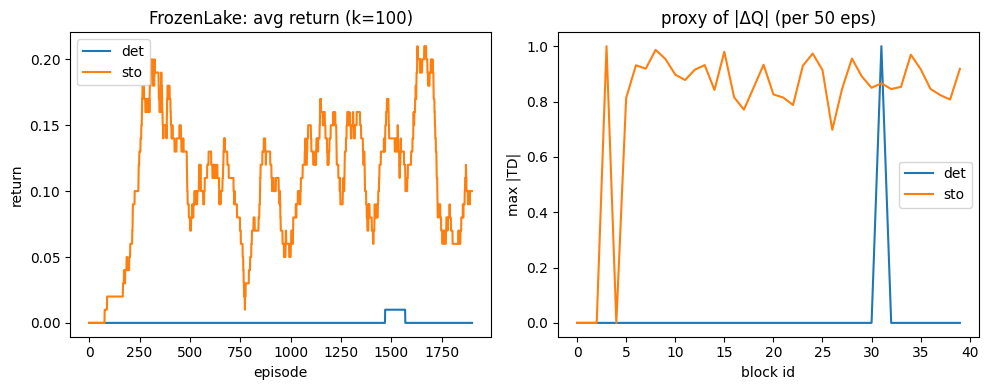

Greedy policy success rate: det=0.00, sto=0.72


: 

In [ ]:
fl_det = make_frozenlake(is_slippery=False)
Q_det, ret_det, d_det = q_learning(fl_det, episodes=2000, alpha=0.7, gamma=0.99, epsilon=0.2, seed=SEED)
sr_det = eval_greedy(fl_det, Q_det, episodes=300, seed=SEED)
fl_det.close()

fl_sto = make_frozenlake(is_slippery=True)
Q_sto, ret_sto, d_sto = q_learning(fl_sto, episodes=2000, alpha=0.7, gamma=0.99, epsilon=0.2, seed=SEED)
sr_sto = eval_greedy(fl_sto, Q_sto, episodes=300, seed=SEED)
fl_sto.close()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(moving_avg(ret_det, 100), label='det')
plt.plot(moving_avg(ret_sto, 100), label='sto')
plt.title('FrozenLake: avg return (k=100)'); plt.xlabel('episode'); plt.ylabel('return'); plt.legend()
plt.subplot(1,2,2); plt.plot(d_det, label='det'); plt.plot(d_sto, label='sto')
plt.title('proxy of |ΔQ| (per 50 eps)'); plt.xlabel('block id'); plt.ylabel('max |TD|'); plt.legend()
plt.tight_layout(); plt.show()

print(f'Greedy policy success rate: det={sr_det:.2f}, sto={sr_sto:.2f}')


### Exercise: ε-жадная и softmax-политики (FrozenLake)

            Реализуйте выбор действия для ε-жадной и softmax-политик и сравните результаты обучения.

In [40]:
# См. реализацию в src/rlcourse/sem01/policies.py; импортируем функции для экспериментов ниже.
epsilon_greedy, softmax_action


(<function rlcourse.sem01.policies.epsilon_greedy(Q: numpy.ndarray, s: int, eps: float) -> int>,
 <function rlcourse.sem01.policies.softmax_action(Q: numpy.ndarray, s: int, tau: float) -> int>)

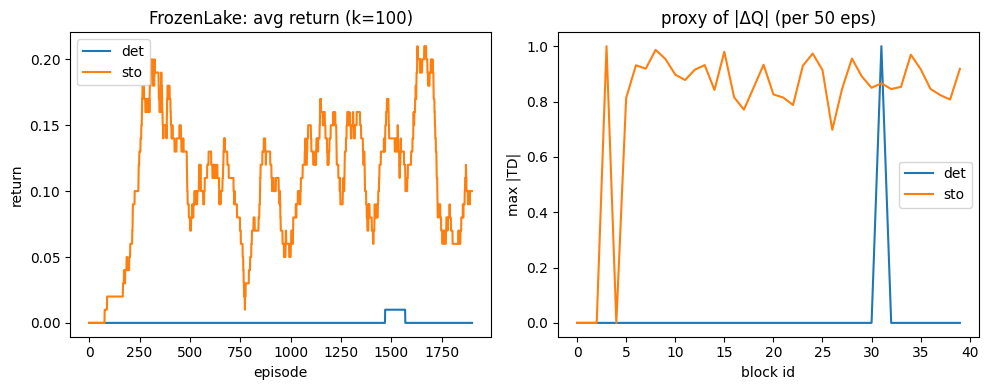

Success rate (greedy): det=0.00, sto=0.72


In [41]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(moving_avg(ret_det, 100), label='det')
plt.plot(moving_avg(ret_sto, 100), label='sto')
plt.title('FrozenLake: avg return (k=100)')
plt.xlabel('episode'); plt.ylabel('return'); plt.legend()
plt.subplot(1,2,2)
plt.plot(d_det, label='det'); plt.plot(d_sto, label='sto')
plt.title('proxy of |ΔQ| (per 50 eps)')
plt.xlabel('block id'); plt.ylabel('max |TD|'); plt.legend()
plt.tight_layout(); plt.show()

print(f'Success rate (greedy): det={sr_det:.2f}, sto={sr_sto:.2f}')


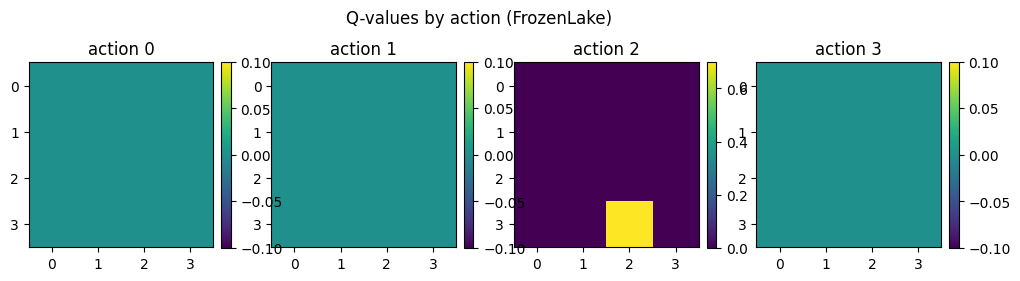

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def plot_Q_heatmaps(Q):
    """
    Plot Q-value heatmaps for each action in a FrozenLake environment.
    
    Parameters:
    Q: numpy array of shape (S, A) where S is number of states and A is number of actions
    """
    S, A = Q.shape
    side = int(np.sqrt(S))
    fig, axes = plt.subplots(1, A, figsize=(12,3))
    for a in range(A):
        ax = axes[a]
        mat = Q[:, a].reshape(side, side)
        im = ax.imshow(mat, cmap='viridis')
        ax.set_title(f'action {a}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle('Q-values by action (FrozenLake)')
    plt.show()

# Plot Q-values for deterministic FrozenLake
plot_Q_heatmaps(Q_det)


## 5. TD(0) с дискретизацией CartPole: пошаговый сценарий

См. `theory.md` §4–5: $ V(s) \leftarrow V(s) + \alpha ( r + \gamma V(s') - V(s) ) $.

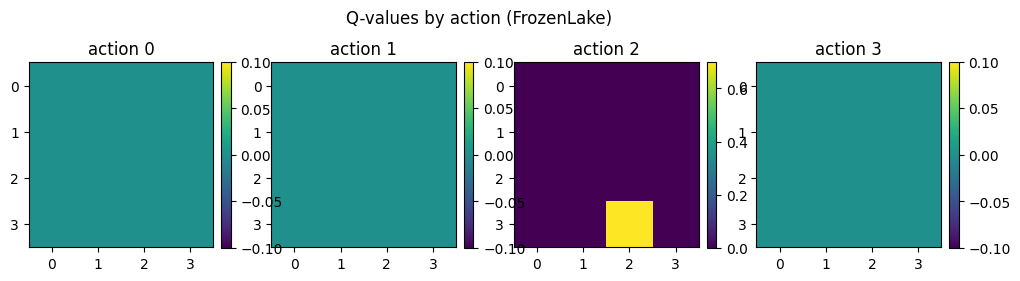

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_Q_heatmaps(Q):
    """
    Plot Q-value heatmaps for each action in a FrozenLake environment.
    
    Parameters:
    Q: numpy array of shape (S, A) where S is number of states and A is number of actions
    """
    S, A = Q.shape
    side = int(np.sqrt(S))
    fig, axes = plt.subplots(1, A, figsize=(12,3))
    for a in range(A):
        ax = axes[a]
        mat = Q[:, a].reshape(side, side)
        im = ax.imshow(mat, cmap='viridis')
        ax.set_title(f'action {a}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle('Q-values by action (FrozenLake)')
    plt.show()

# Plot Q-values for deterministic FrozenLake
plot_Q_heatmaps(Q_det)


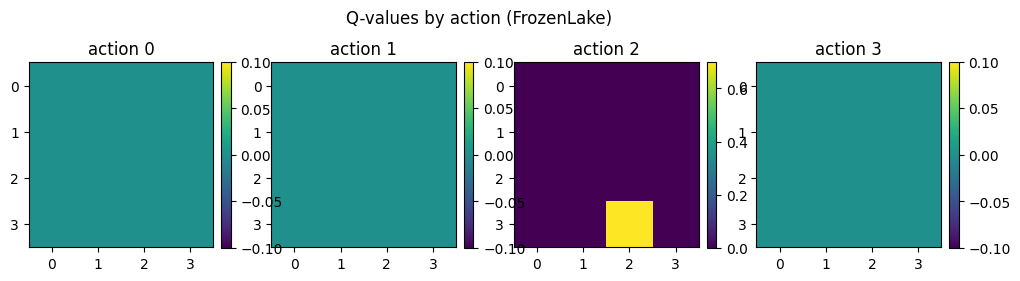

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_Q_heatmaps(Q):
    """
    Plot Q-value heatmaps for each action in a FrozenLake environment.
    
    Parameters:
    Q: numpy array of shape (S, A) where S is number of states and A is number of actions
    """
    S, A = Q.shape
    side = int(np.sqrt(S))
    fig, axes = plt.subplots(1, A, figsize=(12,3))
    for a in range(A):
        ax = axes[a]
        mat = Q[:, a].reshape(side, side)
        im = ax.imshow(mat, cmap='viridis')
        ax.set_title(f'action {a}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle('Q-values by action (FrozenLake)')
    plt.show()

# Plot Q-values for deterministic FrozenLake
plot_Q_heatmaps(Q_det)


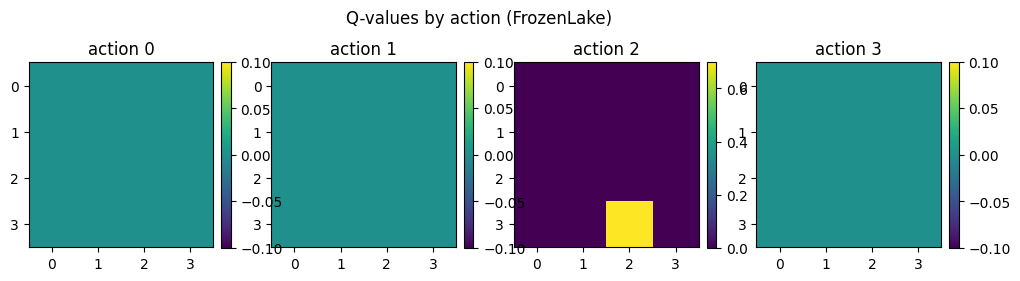

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_Q_heatmaps(Q):
    """
    Plot Q-value heatmaps for each action in a FrozenLake environment.
    
    Parameters:
    Q: numpy array of shape (S, A) where S is number of states and A is number of actions
    """
    S, A = Q.shape
    side = int(np.sqrt(S))
    fig, axes = plt.subplots(1, A, figsize=(12,3))
    for a in range(A):
        ax = axes[a]
        mat = Q[:, a].reshape(side, side)
        im = ax.imshow(mat, cmap='viridis')
        ax.set_title(f'action {a}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle('Q-values by action (FrozenLake)')
    plt.show()

# Plot Q-values for deterministic FrozenLake
plot_Q_heatmaps(Q_det)


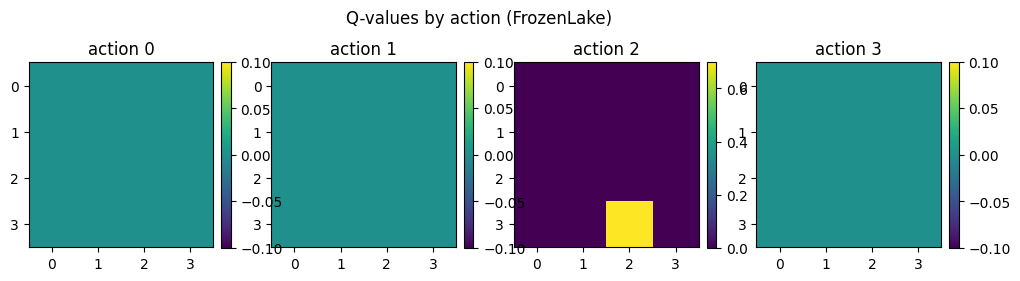

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_Q_heatmaps(Q):
    """
    Plot Q-value heatmaps for each action in a FrozenLake environment.
    
    Parameters:
    Q: numpy array of shape (S, A) where S is number of states and A is number of actions
    """
    S, A = Q.shape
    side = int(np.sqrt(S))
    fig, axes = plt.subplots(1, A, figsize=(12,3))
    for a in range(A):
        ax = axes[a]
        mat = Q[:, a].reshape(side, side)
        im = ax.imshow(mat, cmap='viridis')
        ax.set_title(f'action {a}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle('Q-values by action (FrozenLake)')
    plt.show()

# Plot Q-values for deterministic FrozenLake
plot_Q_heatmaps(Q_det)


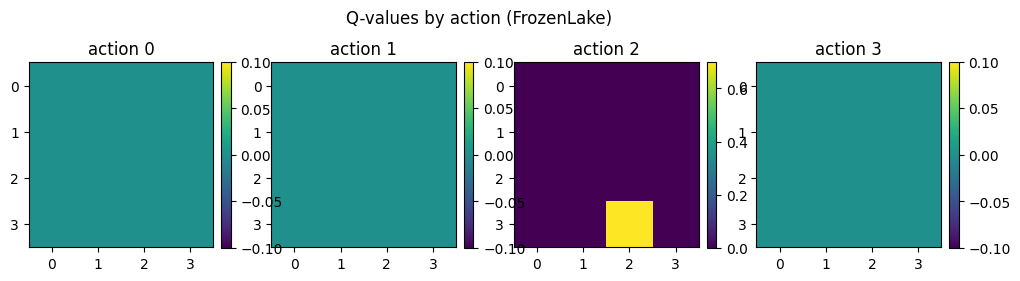

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_Q_heatmaps(Q):
    """
    Plot Q-value heatmaps for each action in a FrozenLake environment.
    
    Parameters:
    Q: numpy array of shape (S, A) where S is number of states and A is number of actions
    """
    S, A = Q.shape
    side = int(np.sqrt(S))
    fig, axes = plt.subplots(1, A, figsize=(12,3))
    for a in range(A):
        ax = axes[a]
        mat = Q[:, a].reshape(side, side)
        im = ax.imshow(mat, cmap='viridis')
        ax.set_title(f'action {a}')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle('Q-values by action (FrozenLake)')
    plt.show()

# Plot Q-values for deterministic FrozenLake
plot_Q_heatmaps(Q_det)


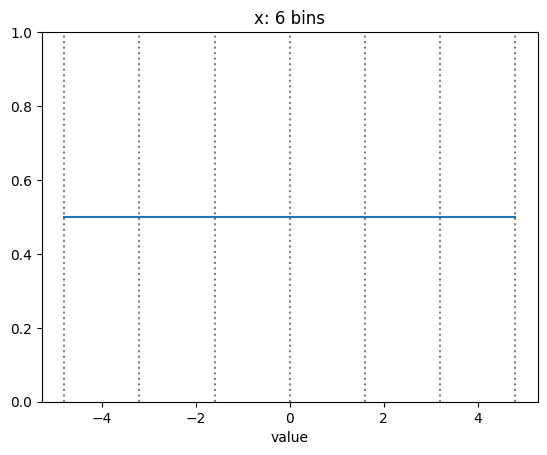

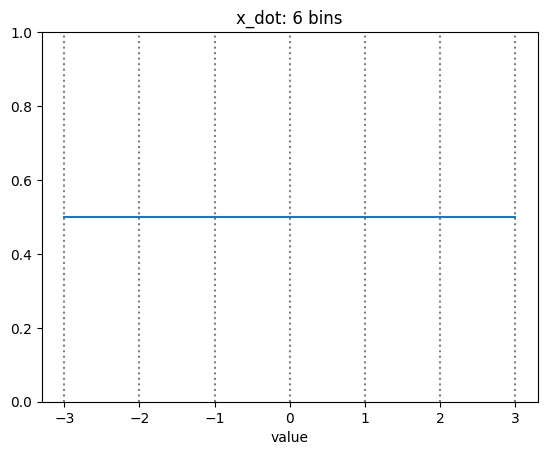

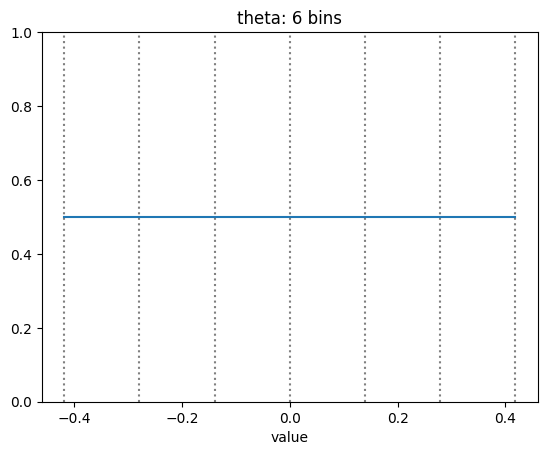

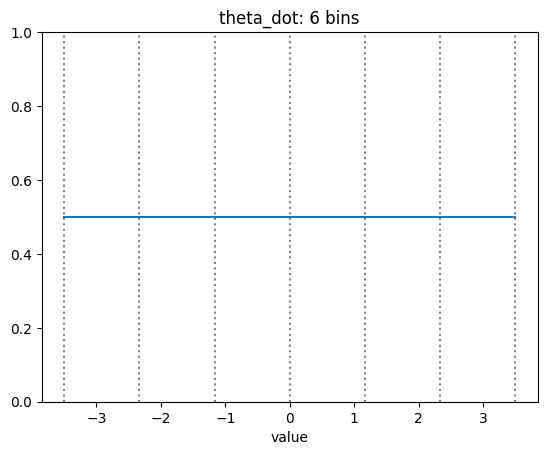

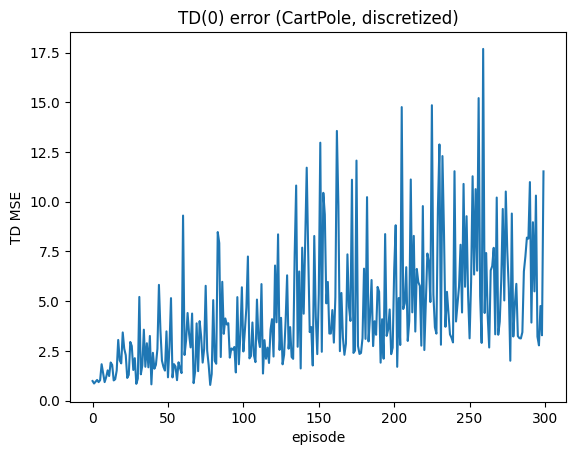

In [37]:
EDGES = make_edges(bounds, BIN_COUNTS)
dims = ['x', 'x_dot', 'theta', 'theta_dot']
for i, e in enumerate(EDGES):
    xs = np.linspace(e[0], e[-1], 400)
    plt.figure()
    plt.vlines(e, ymin=0, ymax=1, colors='gray', linestyles='dotted')
    plt.plot(xs, np.zeros_like(xs) + 0.5)
    plt.ylim(0,1)
    plt.title(f'{dims[i]}: {len(e)-1} bins')
    plt.xlabel('value')
    plt.show()

td_env = make_cartpole()
V_td, mse_history = td0_value_learning(td_env, episodes=300, alpha=0.1, gamma=0.99, seed=SEED)
td_env.close()

plt.figure()
plt.plot(mse_history)
plt.xlabel('episode'); plt.ylabel('TD MSE'); plt.title('TD(0) error (CartPole, discretized)')
plt.show()


### Дискретизация: визуализация бинов и чувствительность

            Посмотрим на границы бинов и влияние их числа на кривую TD‑ошибки.

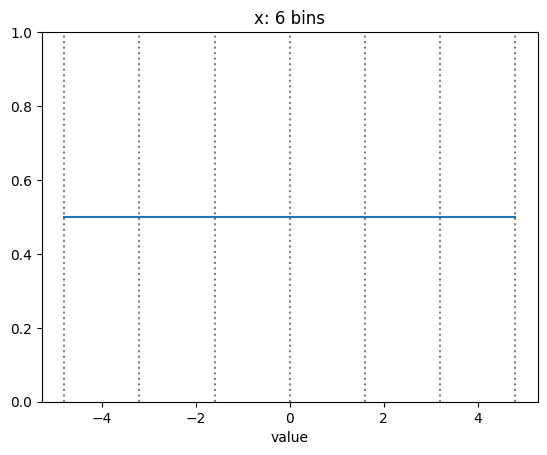

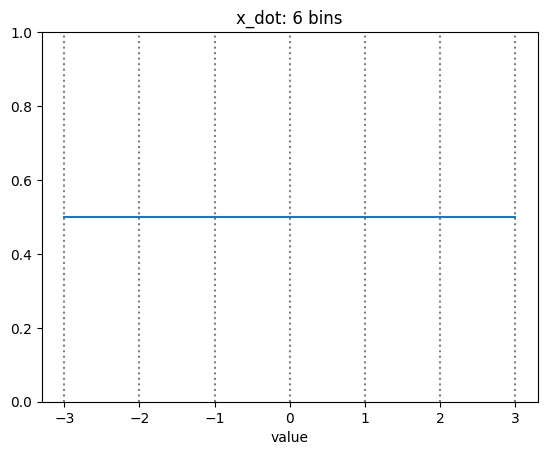

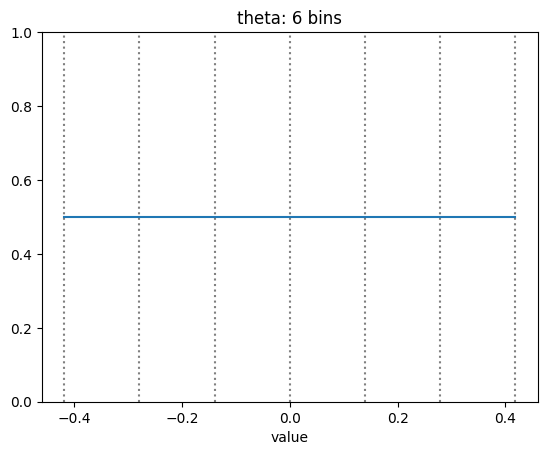

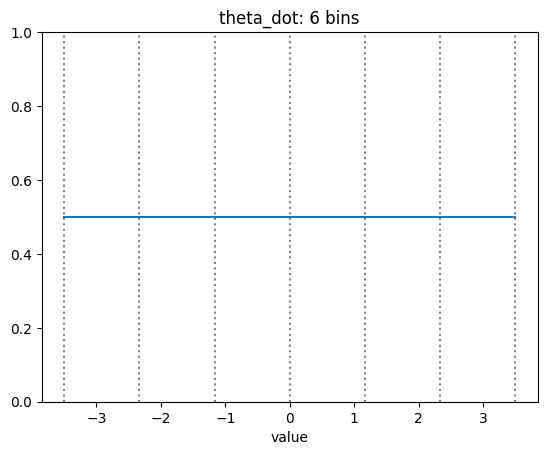

In [38]:
# Визуализация бин-границ
dims = ['x', 'x_dot', 'theta', 'theta_dot']
for i, e in enumerate(EDGES):
    xs = np.linspace(e[0], e[-1], 400)
    plt.figure()
    plt.vlines(e, ymin=0, ymax=1, colors='gray', linestyles='dotted')
    plt.plot(xs, np.zeros_like(xs)+0.5)
    plt.ylim(0,1)
    plt.title(f'{dims[i]}: {len(e)-1} bins')
    plt.xlabel('value')
    plt.show()

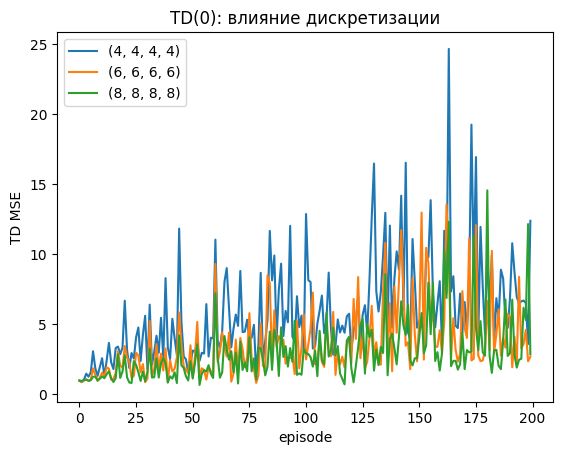

In [39]:
def td0_with_grid(bin_counts, episodes=200, alpha=0.1, gamma=0.99, seed=SEED):
    env_local = make_cartpole()
    _, mse_hist = td0_value_learning(env_local, episodes=episodes, alpha=alpha, gamma=gamma, seed=seed, bin_counts=bin_counts)
    env_local.close()
    return mse_hist

grids = [(4,4,4,4),(6,6,6,6),(8,8,8,8)]
histories = {g: td0_with_grid(g) for g in grids}
plt.figure()
for g, h in histories.items():
    plt.plot(h, label=str(g))
plt.xlabel('episode'); plt.ylabel('TD MSE'); plt.title('TD(0): влияние дискретизации')
plt.legend(); plt.show()


## 6. Сводка и чек-лист

- Связь формул и кода:  
  + $G_t$ → секции 2–3  
  + $V^\pi$ (MC) → секция 3  
  + Q-learning → секция 4  
  + TD(0) → секция 5

### Домашнее задание
1) MC-оценка $V^\pi$ при γ ∈ {0.9, 0.99, 1.0 (эпизодический режим)} — сравнить.
2) На FrozenLake реализовать softmax-политику с температурой τ; сравнить с ε-жадной.

### Контрольные вопросы
1) Как соотносятся уравнения Беллмана для $V^\pi$ и $Q^\pi$?
2) Почему для CartPole применяем дискретизацию в TD(0), а для FrozenLake — нет?
3) Как ε-жадная политика связана с принципом оптимальности?
4) Чем различаются источники ошибки MC и TD, как это видно на графиках?
